# 🎯 Dev 3 — Visualizações, Pitch e Política de Cobrança

**Hackathon FPD TMB | Science Hackathon 2026**

---

## 📋 Mapa de Módulos

| Módulo | O que faz | Precisa de |
|--------|-----------|------------|
| 0 | Setup + verificação de arquivos | nada |
| 1 | Carrega resultados do modelo | `metricas.json`, `submission.csv`, `y_val_results.csv` |
| 2 | Distribuição de scores e faixas de risco | `submission.csv` do Dev 2 |
| 3 | Curvas ROC, KS e PR AUC | `y_val_results.csv` do Dev 2 |
| 4 | Análise por Decil (tabela de ganho) | `y_val_results.csv` do Dev 2 |
| 5 | Feature Importance | `feature_importance.csv` do Dev 1 |
| 6 | Análise por Segmento | `X_val_baseline.csv` + `y_val_results.csv` |
| 7 | Política de Cobrança 12A | `submission.csv` preenchido |
| 8 | Resumo Executivo (exporta .md) | todos os módulos anteriores |
| 9 | Checklist Final | — |

---
## ⏳ Arquivos que você ESPERA dos colegas

- **Dev 1** → `outputs/feature_importance.csv` (colunas: `feature`, `importance`)
- **Dev 2** → `outputs/submission.csv` preenchido (colunas: `pedido_id`, `prob_fpd`, `faixa_risco`)
- **Dev 2** → `outputs/y_val_results.csv` (colunas: `y_true`, `y_pred_proba`)
- **Dev 1/2** → `outputs/metricas.json` atualizado (ROC_AUC, KS, PR_AUC, Recall_at_threshold, threshold_usado)

**Execute cada módulo assim que o arquivo chegar. Eles são independentes!**

---
# Módulo 0 — Setup e Verificação de Arquivos
▶️ Execute SEMPRE primeiro

In [6]:
import os, json, warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from pathlib import Path
warnings.filterwarnings('ignore')

# ── Paleta TMB ──────────────────────────────────────────────────────────────
CORES = {'baixo':'#2ECC71','medio':'#F39C12','alto':'#E67E22','critico':'#E74C3C','neutro':'#3498DB'}
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)

BASE = Path('../outputs')
DATA = Path('../data/processed')
FIGS = BASE / 'figures'
FIGS.mkdir(parents=True, exist_ok=True)

# ── Verificação de arquivos ──────────────────────────────────────────────────
arquivos = {
    'metricas.json':          BASE / 'metricas.json',
    'submission.csv':         BASE / 'submission.csv',
    'y_val_results.csv':      BASE / 'y_val_results.csv',
    'feature_importance.csv': BASE / 'feature_importance.csv',
    'X_val_baseline.csv':     DATA / 'X_val_baseline.csv',
    'X_hold_baseline.csv':    DATA / 'X_hold_baseline.csv',
}

print('=== STATUS DOS ARQUIVOS ===')
for nome, caminho in arquivos.items():
    existe = caminho.exists()
    if existe:
        tam = caminho.stat().st_size / 1024
        print(f'  ✅ {nome:<30} ({tam:.1f} KB)')
    else:
        print(f'  ⏳ {nome:<30} AGUARDANDO...')
print()
print(f'Figuras serão salvas em: {FIGS.resolve()}')

=== STATUS DOS ARQUIVOS ===
  ✅ metricas.json                  (0.3 KB)
  ✅ submission.csv                 (787.6 KB)
  ✅ y_val_results.csv              (327.9 KB)
  ✅ feature_importance.csv         (0.7 KB)
  ✅ X_val_baseline.csv             (5500.7 KB)
  ✅ X_hold_baseline.csv            (5552.5 KB)

Figuras serão salvas em: C:\Users\Murilo\Documents\Hackathon\PIT\outputs\figures


---
# Módulo 1 — Carregamento dos Resultados do Modelo
⏳ **Precisa:** `metricas.json` (Dev 1/2) + `submission.csv` (Dev 2) + `y_val_results.csv` (Dev 2)

In [7]:
# ── Métricas ─────────────────────────────────────────────────────────────────
metricas_path = BASE / 'metricas.json'
if metricas_path.exists():
    with open(metricas_path) as f:
        metricas = json.load(f)
    print('✅ Métricas carregadas:')
    for k, v in metricas.items():
        print(f'   {k}: {v}')
else:
    print('⏳ metricas.json não encontrado — aguardando Dev 1/2')
    metricas = {}

# ── Submission ────────────────────────────────────────────────────────────────
sub_path = BASE / 'submission.csv'
if sub_path.exists():
    sub = pd.read_csv(sub_path)
    if 'prob_fpd' in sub.columns and sub['prob_fpd'].notna().any():
        print(f'\n✅ submission.csv carregado: {len(sub)} linhas')
        print(sub.head(3))
    else:
        print('\n⏳ submission.csv existe mas sem prob_fpd — aguardando Dev 2')
        sub = None
else:
    print('\n⏳ submission.csv não encontrado')
    sub = None

# ── Validação (y_true / y_pred_proba) ─────────────────────────────────────────
val_path = BASE / 'y_val_results.csv'
if val_path.exists():
    val = pd.read_csv(val_path)
    print(f'\n✅ y_val_results.csv carregado: {len(val)} linhas')
    print(val.head(3))
else:
    print('\n⏳ y_val_results.csv não encontrado — aguardando Dev 2')
    val = None

✅ Métricas carregadas:
   ROC_AUC: 0.7842263077657889
   KS: 0.43636965374228587
   PR_AUC: 0.3305622404263398
   Recall_at_threshold: 0.4274284952330155
   threshold_usado: 0.5
   Precision: 0.25783809078146935
   Recall_real: 0.8000968054211036
   Clientes_por_FPD: 3.8784029038112524
   Razao_Normal_FPD: 2.8784029038112524

✅ submission.csv carregado: 23354 linhas
   pedido_id  prob_fpd faixa_risco
0    1945890  0.291269       Medio
1    1945893  0.154054       Baixo
2    1945895  0.353826       Medio

✅ y_val_results.csv carregado: 14999 linhas
   y_true  y_pred_proba
0       0      0.406659
1       0      0.674834
2       0      0.113329


---
# Módulo 2 — Distribuição de Scores e Faixas de Risco
⏳ **Precisa:** `submission.csv` preenchido (Dev 2)

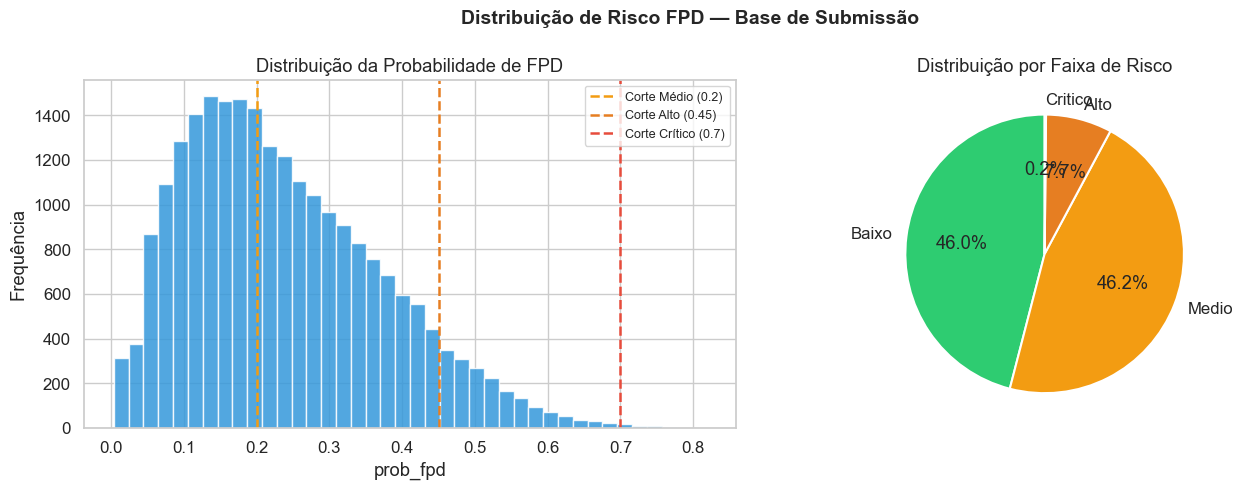


💾 Salvo em ..\outputs\figures/mod2_distribuicao_scores.png


In [8]:
if sub is None or 'prob_fpd' not in sub.columns or not sub['prob_fpd'].notna().any():
    print('⏳ Aguardando submission.csv com prob_fpd preenchido (Dev 2).')
else:
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Distribuição de Risco FPD — Base de Submissão', fontsize=14, fontweight='bold')

    # Histograma de prob_fpd
    axes[0].hist(sub['prob_fpd'], bins=40, color=CORES['neutro'], edgecolor='white', alpha=0.85)
    for thresh, cor, label in [(0.20, CORES['medio'],'Médio'), (0.45, CORES['alto'],'Alto'), (0.70, CORES['critico'],'Crítico')]:
        axes[0].axvline(thresh, color=cor, linestyle='--', linewidth=1.8, label=f'Corte {label} ({thresh})')
    axes[0].set_xlabel('prob_fpd')
    axes[0].set_ylabel('Frequência')
    axes[0].set_title('Distribuição da Probabilidade de FPD')
    axes[0].legend(fontsize=9)

    # Pizza por faixa
    if 'faixa_risco' in sub.columns and sub['faixa_risco'].notna().any():
        contagem = sub['faixa_risco'].value_counts()
        ordem = [f for f in ['Baixo','Medio','Alto','Critico'] if f in contagem.index]
        contagem = contagem.reindex(ordem)
        cores_pizza = [CORES.get(f.lower(), '#95a5a6') for f in ordem]
        axes[1].pie(contagem, labels=contagem.index, autopct='%1.1f%%', colors=cores_pizza,
                    startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
        axes[1].set_title('Distribuição por Faixa de Risco')
    else:
        # Criar faixas automaticamente
        bins   = [0, 0.20, 0.45, 0.70, 1.0]
        labels = ['Baixo','Medio','Alto','Critico']
        sub['faixa_auto'] = pd.cut(sub['prob_fpd'], bins=bins, labels=labels)
        contagem = sub['faixa_auto'].value_counts().reindex(labels)
        cores_pizza = [CORES[f.lower()] for f in labels]
        axes[1].pie(contagem, labels=labels, autopct='%1.1f%%', colors=cores_pizza,
                    startangle=90, wedgeprops={'edgecolor':'white','linewidth':1.5})
        axes[1].set_title('Distribuição por Faixa (cortes automáticos)')

    plt.tight_layout()
    plt.savefig(FIGS / 'mod2_distribuicao_scores.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f'\n💾 Salvo em {FIGS}/mod2_distribuicao_scores.png')

---
# Módulo 3 — Curvas ROC, KS e PR AUC
⏳ **Precisa:** `y_val_results.csv` (Dev 2) com colunas `y_true` e `y_pred_proba`

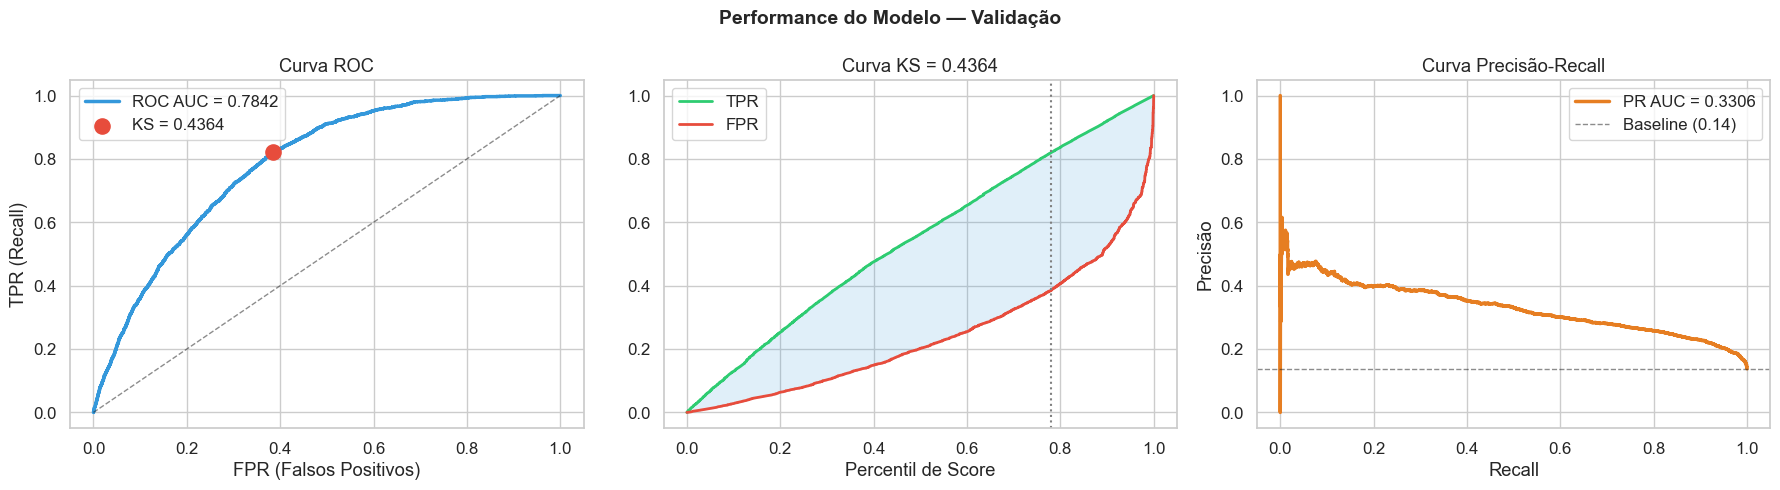


=== MÉTRICAS OPERACIONAIS ===
ROC AUC: 0.7842
KS: 0.4364
PR AUC: 0.3306
Precision da IA: 25.78%
Recall do modelo: 80.01%
Clientes analisados para achar 1 FPD: 3.9
Clientes normais acionados por FPD encontrado: 2.9:1
💾 Salvo em ..\outputs\figures/mod3_curvas_roc_ks_pr.png


In [9]:
from sklearn.metrics import (
    roc_curve,
    auc,
    precision_recall_curve,
    precision_score,
    recall_score
)

if val is None:
    print('⏳ Aguardando y_val_results.csv (Dev 2).')

else:
    y_true = val['y_true'].values
    y_score = val['y_pred_proba'].values

    threshold_usado = metricas.get(
        'threshold_usado',
        0.5
    )

    # ───────────────────────────────────
    # Predição binária usando threshold
    # ───────────────────────────────────
    y_pred = (
        y_score >= threshold_usado
    ).astype(int)

    # ───────────────────────────────────
    # Métricas operacionais
    # ───────────────────────────────────
    precision = precision_score(
        y_true,
        y_pred,
        zero_division=0
    )

    recall_model = recall_score(
        y_true,
        y_pred,
        zero_division=0
    )

    # Quantos clientes analisar
    # para encontrar 1 FPD
    clientes_por_fpd = (
        1 / precision
        if precision > 0
        else np.inf
    )

    # ───────────────────────────────────
    # TP / FP
    # ───────────────────────────────────
    tp = (
        (y_pred == 1) &
        (y_true == 1)
    ).sum()

    fp = (
        (y_pred == 1) &
        (y_true == 0)
    ).sum()

    # Quantos clientes normais
    # para cada FPD encontrado
    razao_normais_fpd = (
        fp / tp
        if tp > 0
        else np.inf
    )

    # ───────────────────────────────────
    # ROC
    # ───────────────────────────────────
    fpr, tpr, thresholds_roc = roc_curve(
        y_true,
        y_score
    )

    roc_auc = auc(fpr, tpr)

    # ───────────────────────────────────
    # KS
    # ───────────────────────────────────
    ks_stat = max(tpr - fpr)
    ks_idx = np.argmax(tpr - fpr)

    # ───────────────────────────────────
    # PR AUC
    # ───────────────────────────────────
    prec, rec, _ = precision_recall_curve(
        y_true,
        y_score
    )

    pr_auc = auc(rec, prec)

    # ───────────────────────────────────
    # Salvar no metricas.json
    # ───────────────────────────────────
    metricas['ROC_AUC'] = float(roc_auc)
    metricas['KS'] = float(ks_stat)
    metricas['PR_AUC'] = float(pr_auc)

    metricas['Precision'] = float(
        precision
    )

    metricas['Recall_real'] = float(
        recall_model
    )

    metricas['Clientes_por_FPD'] = float(
        clientes_por_fpd
    )

    metricas['Razao_Normal_FPD'] = float(
        razao_normais_fpd
    )

    with open(metricas_path, 'w') as f:
        json.dump(
            metricas,
            f,
            indent=4
        )

    # ───────────────────────────────────
    # Criar figura
    # ───────────────────────────────────
    fig, axes = plt.subplots(
        1,
        3,
        figsize=(18, 5)
    )

    fig.suptitle(
        'Performance do Modelo — Validação',
        fontsize=14,
        fontweight='bold'
    )

    # ───────────────────────────────────
    # ROC Curve
    # ───────────────────────────────────
    axes[0].plot(
        fpr,
        tpr,
        color=CORES['neutro'],
        lw=2.5,
        label=f'ROC AUC = {roc_auc:.4f}'
    )

    axes[0].plot(
        [0, 1],
        [0, 1],
        'k--',
        lw=1,
        alpha=0.5
    )

    axes[0].scatter(
        fpr[ks_idx],
        tpr[ks_idx],
        s=120,
        color=CORES['critico'],
        zorder=5,
        label=f'KS = {ks_stat:.4f}'
    )

    axes[0].set_xlabel(
        'FPR (Falsos Positivos)'
    )

    axes[0].set_ylabel(
        'TPR (Recall)'
    )

    axes[0].set_title(
        'Curva ROC'
    )

    axes[0].legend()

    # ───────────────────────────────────
    # KS Plot
    # ───────────────────────────────────
    pcts = np.linspace(
        0,
        1,
        len(thresholds_roc)
    )

    axes[1].plot(
        pcts,
        tpr,
        color=CORES['baixo'],
        lw=2,
        label='TPR'
    )

    axes[1].plot(
        pcts,
        fpr,
        color=CORES['critico'],
        lw=2,
        label='FPR'
    )

    axes[1].fill_between(
        pcts,
        tpr,
        fpr,
        alpha=0.15,
        color=CORES['neutro']
    )

    axes[1].axvline(
        pcts[ks_idx],
        color='gray',
        linestyle=':',
        lw=1.5
    )

    axes[1].set_xlabel(
        'Percentil de Score'
    )

    axes[1].set_title(
        f'Curva KS = {ks_stat:.4f}'
    )

    axes[1].legend()

    # ───────────────────────────────────
    # PR Curve
    # ───────────────────────────────────
    axes[2].plot(
        rec,
        prec,
        color=CORES['alto'],
        lw=2.5,
        label=f'PR AUC = {pr_auc:.4f}'
    )

    baseline = y_true.mean()

    axes[2].axhline(
        baseline,
        color='k',
        linestyle='--',
        lw=1,
        alpha=0.5,
        label=f'Baseline ({baseline:.2f})'
    )

    axes[2].set_xlabel(
        'Recall'
    )

    axes[2].set_ylabel(
        'Precisão'
    )

    axes[2].set_title(
        'Curva Precisão-Recall'
    )

    axes[2].legend()

    plt.tight_layout()

    plt.savefig(
        FIGS /
        'mod3_curvas_roc_ks_pr.png',
        dpi=150,
        bbox_inches='tight'
    )

    plt.show()

    # ───────────────────────────────────
    # Print executivo
    # ───────────────────────────────────
    print('\n=== MÉTRICAS OPERACIONAIS ===')

    print(
        f'ROC AUC: {roc_auc:.4f}'
    )

    print(
        f'KS: {ks_stat:.4f}'
    )

    print(
        f'PR AUC: {pr_auc:.4f}'
    )

    print(
        f'Precision da IA: '
        f'{precision:.2%}'
    )

    print(
        f'Recall do modelo: '
        f'{recall_model:.2%}'
    )

    print(
        f'Clientes analisados '
        f'para achar 1 FPD: '
        f'{clientes_por_fpd:.1f}'
    )

    print(
        f'Clientes normais '
        f'acionados por FPD '
        f'encontrado: '
        f'{razao_normais_fpd:.1f}:1'
    )

    print(
        f'💾 Salvo em '
        f'{FIGS}/mod3_curvas_roc_ks_pr.png'
    )

---
# Módulo 4 — Análise por Decil (Tabela de Ganho)
⏳ **Precisa:** `y_val_results.csv` (Dev 2)

=== TABELA DE GANHO POR DECIL ===
 decil  n_total  n_fpd  taxa_fpd_%  %_fpd_capturado  %_pop_acionada  lift
     1     1500    576        38.4             27.9            10.0  2.79
     2     1500    430        28.7             48.7            20.0  2.08
     3     1500    309        20.6             63.6            30.0  1.50
     4     1500    272        18.1             76.8            40.0  1.31
     5     1499    196        13.1             86.3            50.0  0.95
     6     1500    142         9.5             93.2            60.0  0.69
     7     1500     72         4.8             96.7            70.0  0.35
     8     1500     45         3.0             98.8            80.0  0.22
     9     1500     20         1.3             99.8            90.0  0.09
    10     1500      4         0.3            100.0           100.0  0.02


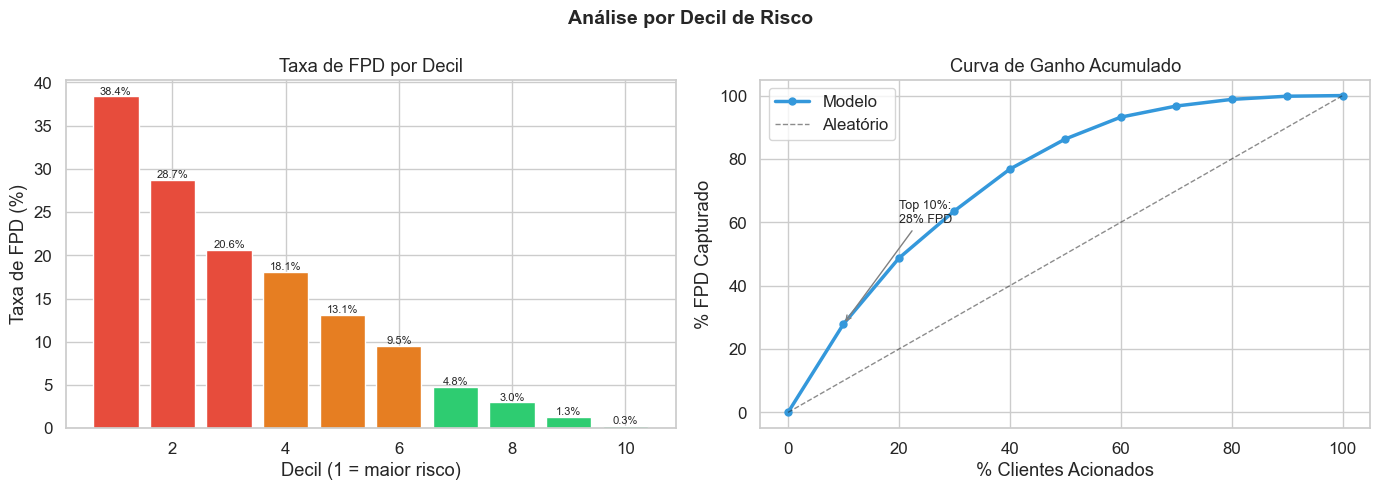

💾 Salvo: ..\outputs\figures/mod4_analise_decil.png e outputs/tabela_decil.csv


In [10]:
if val is None:
    print('⏳ Aguardando y_val_results.csv (Dev 2).')
else:
    df_dec = val.copy()
    df_dec['decil'] = pd.qcut(df_dec['y_pred_proba'], q=10, labels=False, duplicates='drop')
    df_dec['decil'] = 10 - df_dec['decil']  # decil 1 = maior risco

    tabela = df_dec.groupby('decil').agg(
        n_total=('y_true','count'),
        n_fpd=('y_true','sum'),
        prob_media=('y_pred_proba','mean')
    ).reset_index()
    tabela['taxa_fpd_%']    = (tabela['n_fpd'] / tabela['n_total'] * 100).round(1)
    tabela['%_fpd_capturado'] = (tabela['n_fpd'].cumsum() / tabela['n_fpd'].sum() * 100).round(1)
    tabela['%_pop_acionada']  = (tabela['n_total'].cumsum() / tabela['n_total'].sum() * 100).round(1)
    tabela['lift']           = (tabela['taxa_fpd_%'] / (tabela['n_fpd'].sum()/tabela['n_total'].sum()*100)).round(2)

    print('=== TABELA DE GANHO POR DECIL ===')
    print(tabela[['decil','n_total','n_fpd','taxa_fpd_%','%_fpd_capturado','%_pop_acionada','lift']].to_string(index=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle('Análise por Decil de Risco', fontsize=14, fontweight='bold')

    # Taxa FPD por decil
    bars = axes[0].bar(tabela['decil'], tabela['taxa_fpd_%'],
                       color=[CORES['critico'] if d<=3 else CORES['alto'] if d<=6 else CORES['baixo'] for d in tabela['decil']])
    axes[0].set_xlabel('Decil (1 = maior risco)')
    axes[0].set_ylabel('Taxa de FPD (%)')
    axes[0].set_title('Taxa de FPD por Decil')
    axes[0].bar_label(bars, fmt='%.1f%%', fontsize=8)

    # Curva de ganho
    axes[1].plot([0]+tabela['%_pop_acionada'].tolist(), [0]+tabela['%_fpd_capturado'].tolist(),
                 color=CORES['neutro'], lw=2.5, marker='o', markersize=5, label='Modelo')
    axes[1].plot([0,100],[0,100],'k--', lw=1, alpha=0.5, label='Aleatório')
    axes[1].set_xlabel('% Clientes Acionados')
    axes[1].set_ylabel('% FPD Capturado')
    axes[1].set_title('Curva de Ganho Acumulado')
    axes[1].legend()

    # Destaque top 10%
    top1 = tabela[tabela['decil']==1]
    if not top1.empty:
        axes[1].annotate(f"Top 10%:\n{top1['%_fpd_capturado'].values[0]:.0f}% FPD",
                        xy=(top1['%_pop_acionada'].values[0], top1['%_fpd_capturado'].values[0]),
                        xytext=(20,60), textcoords='data',
                        arrowprops=dict(arrowstyle='->', color='gray'), fontsize=9)

    plt.tight_layout()
    plt.savefig(FIGS / 'mod4_analise_decil.png', dpi=150, bbox_inches='tight')
    plt.show()
    tabela.to_csv(BASE / 'tabela_decil.csv', index=False)
    print(f'💾 Salvo: {FIGS}/mod4_analise_decil.png e outputs/tabela_decil.csv')